In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import string
import nltk

from nltk.corpus import stopwords

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
# Load dataset

df = pd.read_csv(
    "/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv",
    encoding='latin-1'
)

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [9]:
# Keep required columns only
df = df[['v1', 'v2']]

# Rename columns
df.columns = ['label', 'message']

# Display dataset
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
print("Dataset Shape:", df.shape)

print("\nClass Distribution:")
print(df['label'].value_counts())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Info:")
print(df.info())

Dataset Shape: (5572, 2)

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Missing Values:
label      0
message    0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None


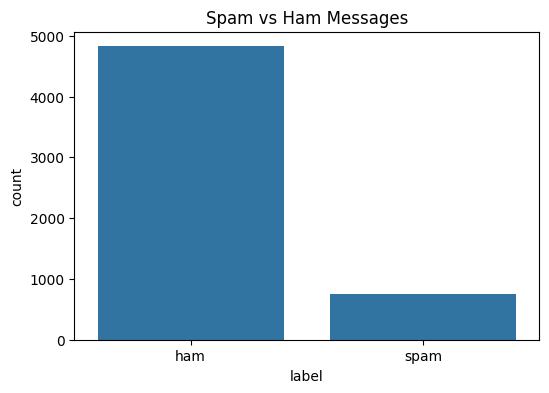

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df['label']
)

plt.title("Spam vs Ham Messages")
plt.show()

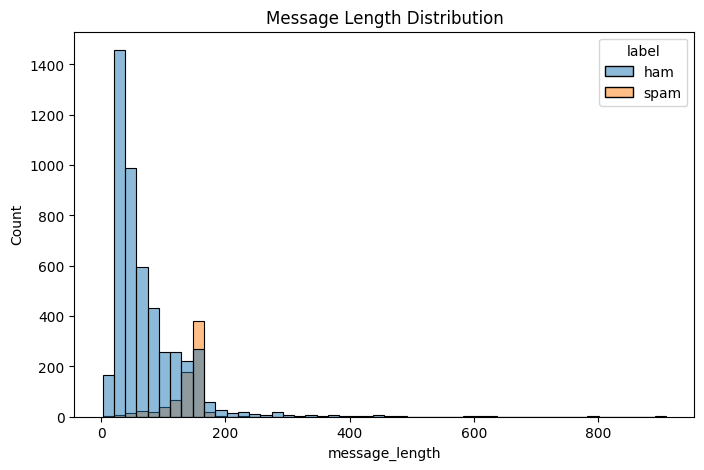

In [12]:
# Add message length column
df['message_length'] = df['message'].apply(len)

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='message_length',
    hue='label',
    bins=50
)

plt.title("Message Length Distribution")
plt.show()

In [13]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    # lowercase
    text = text.lower()

    # remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # tokenize
    words = text.split()

    # remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

# Apply cleaning
df['clean_message'] = df['message'].apply(clean_text)

df.head()

,label,message,message_length,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,29,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,49,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,nah dont think goes usf lives around though


In [14]:
df['label_num'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,label,message,message_length,clean_message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazy available bugis n great ...,0
1,ham,Ok lar... Joking wif u oni...,29,ok lar joking wif u oni,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry wkly comp win fa cup final tkts st ...,1
3,ham,U dun say so early hor... U c already then say...,49,u dun say early hor u c already say,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,nah dont think goes usf lives around though,0


In [16]:
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(
    df['clean_message']
)

y = df['label_num']

print("Feature Matrix Shape:")
print(X.shape)

Feature Matrix Shape:
(5572, 8467)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (4457, 8467)
Testing Shape: (1115, 8467)


In [18]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

# Prediction
y_pred_nb = nb_model.predict(X_test)

# Accuracy
print("Accuracy:",
      accuracy_score(
          y_test,
          y_pred_nb
      ))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    y_pred_nb
))

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_nb
))

Accuracy: 0.967713004484305

Confusion Matrix:
[[965   0]
 [ 36 114]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.76      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



In [19]:
lr_model = LogisticRegression()

lr_model.fit(
    X_train,
    y_train
)

# Prediction
y_pred_lr = lr_model.predict(
    X_test
)

# Accuracy
print("Accuracy:",
      accuracy_score(
          y_test,
          y_pred_lr
      ))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    y_pred_lr
))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_lr
))

Accuracy: 0.947085201793722

Confusion Matrix:
[[961   4]
 [ 55  95]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       965
           1       0.96      0.63      0.76       150

    accuracy                           0.95      1115
   macro avg       0.95      0.81      0.87      1115
weighted avg       0.95      0.95      0.94      1115



In [20]:
results = pd.DataFrame({
    'Model': [
        'Naive Bayes',
        'Logistic Regression'
    ],
    'Accuracy': [
        accuracy_score(
            y_test,
            y_pred_nb
        ),
        accuracy_score(
            y_test,
            y_pred_lr
        )
    ]
})

results

,Model,Accuracy
0,Naive Bayes,0.967713
1,Logistic Regression,0.947085


In [21]:
message = [
    "Congratulations! You won ₹50000 claim now"
]

# Clean message
cleaned_message = [
    clean_text(message[0])
]

# Convert into TF-IDF
message_vector = tfidf.transform(
    cleaned_message
)

# Predict
prediction = lr_model.predict(
    message_vector
)

if prediction[0] == 1:
    print("Spam Message")
else:
    print("Ham Message")

Spam Message


In [22]:
message = [
    "Hey bro are you coming to class today?"
]

cleaned_message = [
    clean_text(message[0])
]

message_vector = tfidf.transform(
    cleaned_message
)

prediction = lr_model.predict(
    message_vector
)

if prediction[0] == 1:
    print("Spam Message")
else:
    print("Ham Message")

Ham Message
